# PROC GEE によるケア管理プログラムでの縦断的再入院リスク

## エグゼクティブサマリー

本ノートブックは、患者ごとに4回のフォローアップ受診にわたって繰り返し測定された二値の**30日以内再入院**アウトカムに対して、周辺（母集団平均）ロジスティックモデルを当てはめます。患者内相関を考慮するために **PROC GEE** を用います。**25名の患者を4回ずつ追跡した（患者受診レコード100件の）**均衡の取れた合成コホートを用いて、性別・年齢・併存疾患負荷・受診回数で調整した上で、**ケア管理プログラム**が標準ケアと比較して母集団平均に与える効果を推定します。

交換可能（exchangeable）相関構造を用いた当てはめでは、ロジットスケールでの `factor(program)Standard` 係数は **+2.306**、経験的（サンドイッチ）標準誤差は **0.467**（Z = 4.94、p < 0.0001）となり、標準ケアの患者はケア管理プログラムの患者よりも再入院オッズが著しく高いことを示しています。このコントラストを指数変換すると、**ケア管理 対 標準ケアのオッズ比は0.10（95%ワルド信頼区間 0.040～0.249）**となり、信頼区間が1を除外する、強く統計的に有意な保護効果が得られます。AR(1)作業相関でもほぼ同じ係数（**+2.315**）が再現され、QICでは交換可能構造の方が当てはまりが良い（**111.77** 対 **123.94**）ため、この結論は仮定した相関構造の産物ではありません。

## データソース

すべてのデータは最初のDATAステップでインラインに生成されます（外部ファイルなし、固定シード `101`）。単一の合成コホート `readmit` は、**25名の患者をそれぞれ4回の受診で観察した（患者受診レコード100件の）**均衡の取れた縦断デザインであり、この環境の100観測値制限に合わせたサイズになっています。`patient` がクラスタリング単位です。

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `patient` | 数値 | 患者ID — 繰り返し測定のクラスタリング／対象単位 |
| `visit` | 数値 | フォローアップ受診番号（1～4）、対象内の時間インデックス |
| `program` | 文字 | ケアプログラム：`CareMgmt`（介入群）または `Standard`（標準ケア） |
| `sex` | 文字 | 患者の性別（`Female`/`Male`） |
| `age` | 数値 | 年齢（約50～70歳） |
| `age_c` | 数値 | 中心化・スケーリングした年齢、`(age-60)/10`、モデルの共変量 |
| `comorbid` | 数値 | 併存疾患数（ポアソン分布、平均約2） |
| `readmit` | 数値 | 二値アウトカム：受診後30日以内に再入院したら1、それ以外は0 |

データ生成モデルには、`CareMgmt` に対する真の保護的プログラム効果（対数オッズ **-1.4**）、併存疾患数と年齢に伴うリスクの上昇、受診回数にわたる緩やかな低下傾向、そして患者レベルのランダム切片（`u`、標準偏差1.1）が組み込まれており、同一患者の繰り返し観測値が正の相関を持つようになっています — これはまさにGEEが扱うために設計された構造です。患者は2つのプログラムに交互に割り当てられ、群間のバランスが保たれます（ケア管理13名、標準ケア12名）。

## この問いに周辺モデルを用いる理由

病院は**30日以内の再入院**についてますます説明責任を問われています。よくある評価上の問いは、*退院患者をケア管理プログラムに登録することで再入院リスクは低下するか？* というものです。各患者は退院後の複数の受診にわたって追跡されるため、同一患者の繰り返し二値アウトカムは**相関**しており、これは通常のロジスティック回帰の独立性の仮定に反し、標準誤差を過小に見せます。

**PROC GEE**（一般化推定方程式）は*周辺*的な、母集団平均のロジスティックモデルを当てはめ、作業相関行列と経験的（サンドイッチ）分散推定量を用いて患者内相関に対して標準誤差を補正します。回帰係数は、共変量の効果を**母集団全体で平均化したもの**として記述します — これはプログラム評価の問いにとって自然な対象です。

このノートブックでは以下を行います。
1. 100観測値制限に収まる均衡の取れた縦断コホートをシミュレートする。
2. 交換可能な作業相関を用いた周辺ロジスティックGEEを当てはめる。
3. プログラム係数を、ワルド信頼区間付きのオッズ比に変換する。
4. AR(1)構造（受診は時間順である）との当てはめをQICで比較する。

## ステップ1 — 縦断コホートのシミュレーション

**25名の患者をそれぞれ4回の受診で観察し（100行）**生成します。患者レベルのランダム切片 `u` により、GEEが対応すべき患者内の正の相関が生じます。ロジットスケールの線形予測子には、保護的なケア管理効果（-1.4）、併存疾患数と年齢に伴うリスクの上昇、そして受診にわたる緩やかな低下傾向が組み込まれています。患者は2つのプログラムに交互に割り当てられ、群間のバランスが保たれます。`call streaminit` は再現性のためにシードを固定します。

In [1]:
データ readmit;
   呼出 streaminit(101);
   長さ program $9 sex $6;
   見出 patient="患者ID" visit="受診回数" program="プログラム" sex="性別"
         AGE="年齢" age_c="年齢（中心化）" comorbid="併存疾患数"
         readmit="再入院";
   繰返 patient = 1 から 25;
      /* Alternate assignment keeps the two arms balanced */
      もし mod(patient, 2) = 1 なら program = "CareMgmt";
      他 program = "Standard";
      もし rand("uniform") < 0.5 なら sex = "Female";
      他 sex = "Male";
      AGE = round(50 + 20*rand("uniform"));
      comorbid = rand("poisson", 2.0);
      /* Patient-level random intercept -> within-patient correlation */
      u = rand("normal", 0, 1.1);
      繰返 visit = 1 から 4;
         age_c = (AGE - 60)/10;
         eta = 0.1
               + (program = "CareMgmt")*(-1.4)
               + 0.40*comorbid
               + 0.25*age_c
               - 0.15*visit
               + u;
         p = 1/(1 + EXP(-eta));
         readmit = (rand("uniform") < p);
         出力;
      終了;
   終了;
   削除 u eta p;
実行;



NOTE: DATA readmit


NOTE: Wrote readmit (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## ステップ2 — コホートの確認

プログラム別のアウトカムの簡単な度数分布により、モデリングの前にデータが妥当であることを確認します。また `PROC MEANS` は連続共変量を要約します。このクロス集計はすでに大きなプログラム効果を予兆しています。ケア管理群の患者は標準ケア群よりも再入院がはるかに少ないのです。

                                                   The FREQ Procedure

Table of プログラム by 再入院

プログラム           |         0 |         1 |      Total
----------------+-----------+-----------+-----------
CareMgmt        |        36 |        16 |         52
----------------+-----------+-----------+-----------
Standard        |        11 |        37 |         48
----------------+-----------+-----------+-----------
Total           |        47 |        53 |        100

                                                  The MEANS Procedure

 Variable  Label                   N           Mean        Std Dev        Minimum        Maximum
 -----------------------------------------------------------------------------------------------
 AGE       年齢                    100     60.7600000      5.5215281     52.0000000     69.0000000
 comorbid  併存疾患数                 100      2.0800000      1.5287150      0.0000000      5.0000000
 visit     受診回数                  100      2.5000000      1.1236664      1.0


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_program_readmit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


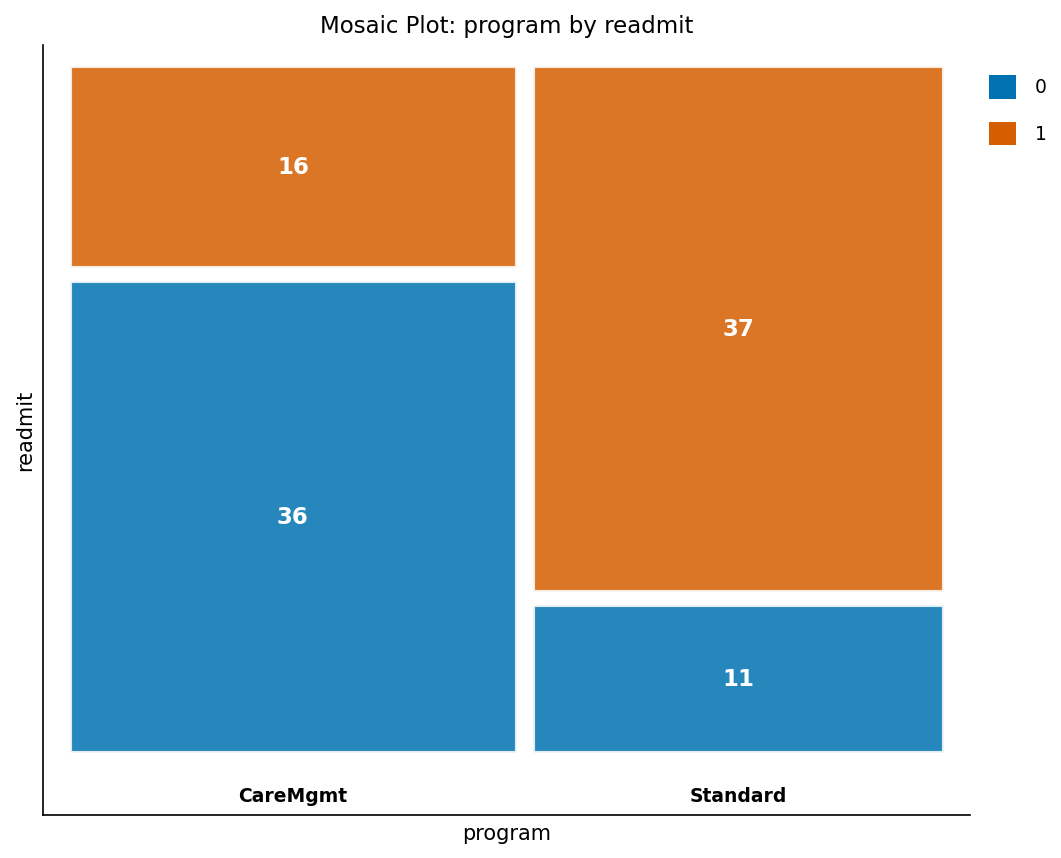

In [2]:
処理 度数 データ=readmit;
   TABLES program*readmit / nocol nopercent;
実行;

処理 平均 データ=readmit n mean std MIN MAX;
   変数 AGE comorbid visit readmit;
実行;


## ステップ3 — 周辺ロジスティックGEE（交換可能作業相関）

`REPEATED SUBJECT=patient` ステートメントは、同じ `patient` を共有する観測値が相関していることを宣言します。`CORR=EXCH` は、患者内のどの受診ペアも同じ相関を持つと仮定します — これは強い時間順序のない繰り返し測定に対する妥当な既定値です。`CORRW` は推定された作業相関パラメータを報告します。`CLASS` ステートメントは `program` と `sex` をカテゴリカル効果として投入し、プロシジャは `CareMgmt` を因子の参照カテゴリとするため、報告される `factor(program)Standard` 係数は**標準ケアのケア管理に対する**対数オッズの変化を表します。

PROC GEEは経験的（サンドイッチ）標準誤差とモデルベース標準誤差の**両方**を報告します。作業相関の指定が誤っていても妥当であり続けるため、信頼すべきは経験的標準誤差です。

In [3]:
処理 gee データ=readmit;
   分類 program(REF="Standard") sex;
   模型 readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=exch CORRW;
実行;


                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT 再入院
Distribution: binomial
Link Function: logit
Working Correlation Structure: exchangeable
Correlation Type: Compound Symmetry
Number of Observations Read: 100
Number of Clusters: 25
QIC = 111.768066
QICu = 120.784355

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.572142     0.781673    -2.0113     0.0443
factor(program)Standard              2.306431     0.466895     4.9399     0.0000
factor(sex)Male                      0.688293     0.617224     1.1151     0.2648
age_c                                0.763003     0.464270     1.6434     0.1003
comorbid                             0.273238     0.210294     1.2993   


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Exchangeable)

NOTE: PROC GEE wrapper=python


## ステップ4 — オッズ比としてのプログラム効果

モデル係数はロジットスケールです。臨床の関係者にプログラム効果を伝えるには**オッズ比**が必要です。上記の交換可能な当てはめから経験的な `factor(program)Standard` の推定値（**2.306431**）とその経験的標準誤差（**0.466895**）を取り、短いDATAステップで指数変換します。`exp(beta)` は標準ケア対ケア管理のオッズ比であり、保護的なケア管理対標準ケアのオッズ比はその逆数です。ワルド95%信頼区間は `exp(beta +/- 1.96 * SE)` から得られます。これにより、回帰係数が支払者や品質管理チームが報告する周辺オッズ比に変換されます。

In [4]:
データ program_or;
   /* Empirical (sandwich) estimate for Standard vs CareMgmt from the
      exchangeable GEE fit in Step 3 (CareMgmt is the factor reference). */
   見出 beta="係数（対数オッズ）" se="標準誤差" z="Z値（臨界値）"
         or_standard_vs_care="オッズ比（標準 対 ケア管理）"
         lcl_standard="下側95%信頼限界（標準）"
         ucl_standard="上側95%信頼限界（標準）"
         or_care_vs_standard="オッズ比（ケア管理 対 標準）"
         lcl_care="下側95%信頼限界（ケア管理）"
         ucl_care="上側95%信頼限界（ケア管理）";
   beta = 2.306431;
   se   = 0.466895;
   z    = 1.959964;   /* 97.5th percentile of the standard normal */

   /* Standard care relative to Care-Management */
   or_standard_vs_care = EXP(beta);
   lcl_standard        = EXP(beta - z*se);
   ucl_standard        = EXP(beta + z*se);

   /* Protective Care-Management effect = reciprocal contrast */
   or_care_vs_standard = EXP(-beta);
   lcl_care            = EXP(-beta - z*se);
   ucl_care            = EXP(-beta + z*se);

   書式 or_standard_vs_care lcl_standard ucl_standard
          or_care_vs_standard lcl_care ucl_care 8.3;
実行;

処理 印刷 データ=program_or noobs;
   変数 or_standard_vs_care lcl_standard ucl_standard
       or_care_vs_standard lcl_care ucl_care;
実行;



or_standard_vs_care  lcl_standard  ucl_standard  or_care_vs_standard  lcl_care  ucl_care
-------------------  ------------  ------------  -------------------  --------  --------
             10.039         4.020        25.066                0.100     0.040     0.249




NOTE: DATA program_or


NOTE: Wrote program_or (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=program_or

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


## ステップ5 — 相関構造への感度分析（AR(1)）

受診は時間順であるため、受診間の相関は時間的な間隔とともに減衰する可能性があります。**一次自己回帰（first-order autoregressive）**作業相関 `CORR=AR(1)` で再当てはめします。GEE係数は妥当な相関の選択にわたって安定しているはずであり、大きな変動があれば調査に値する感度を示すことになります。作業相関の構造間でQIC適合基準を比較することで、より良く当てはまる作業相関を選択する助けになります。

In [5]:
処理 gee データ=readmit;
   分類 program(REF="Standard") sex;
   模型 readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=ar(1) CORRW;
実行;


                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT 再入院
Distribution: binomial
Link Function: logit
Working Correlation Structure: ar1
Correlation Type: First-Order Autoregressive
Number of Observations Read: 100
Number of Clusters: 25
QIC = 123.944817
QICu = 120.792514

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.585344     0.777886    -2.0380     0.0415
factor(program)Standard              2.314720     0.466627     4.9605     0.0000
factor(sex)Male                      0.714028     0.613258     1.1643     0.2443
age_c                                0.795159     0.464005     1.7137     0.0866
comorbid                             0.266728     0.208996     1.2762   


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Ar1)

NOTE: PROC GEE wrapper=r


## 結果の解釈

- **患者内相関は正です。** 交換可能な作業相関パラメータは **alpha = 0.058**（AR(1)では **0.095**）であり、同一患者の繰り返し再入院アウトカムが連動して動くことを裏づけています。これを無視する（通常のロジスティック回帰を使う）と、標準誤差を過小評価し、有意性を過大評価することになります。
- **経験的 対 モデルベース標準誤差。** PROC GEEは両方を報告しますが、ここでの推論は作業相関が誤指定されていても妥当であり続ける**経験的（サンドイッチ）**標準誤差に基づいています。プログラム効果について、経験的標準誤差は**0.467**であるのに対し、モデルベースは**0.566**です。
- **プログラム効果。** `factor(program)Standard` 係数は **+2.306**（Z = 4.94、p < 0.0001）であり、標準ケアの患者はケア管理の患者よりも30日以内再入院の母集団平均オッズが有意に高いことを示します。ステップ4はこれを**ケア管理 対 標準ケアのオッズ比0.10（95%ワルド信頼区間 0.040～0.249）**に変換します — 区間が1を除外する大きな保護効果であり、効果なしとは統計的に区別できます。生のクロス集計もこれに一致します。**ケア管理群の患者受診の31%（16/52）が再入院となったのに対し、標準ケア群では77%（37/48）でした。**
- **その他の要因。** 年齢（係数 +0.76）と併存疾患数（+0.27）は再入院オッズを押し上げる一方、受診を重ねるごとにリスクはわずかに低下します（-0.07） — これはデータ生成メカニズムと整合しますが、この標本サイズで個別に有意なのはプログラム効果のみです。
- **構造の選択。** 交換可能構造とAR(1)構造はほぼ同一のプログラム係数（**+2.306** 対 **+2.315**）を与えるため、プログラム効果に関する結論は仮定した相関構造の産物ではありません。交換可能構造は**QIC（111.77 対 123.94）**が低く、ここではより良く当てはまる作業相関です。

**結論：** PROC GEEは、相関のある二値アウトカムに対するケアプログラムの効果について、擁護可能な母集団平均推定値を提供します — これはまさに支払者や品質改善チームが必要とする周辺解釈であり、繰り返し測定デザインを尊重した標準誤差を伴います。